In [ ]:
#Importing essential libraries

import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Downloading directly

!wget -q https://zenodo.org/record/1188976/files/Audio_Speech_Actors_01-24.zip -O speech.zip
!unzip -q speech.zip -d ravdess_data
print("Download complete!")

Download complete!


In [ ]:
emotion_map = {
    '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
    '05': 'angry', '06': 'fearful', '07': 'disgust', '08': 'surprised'
}

data_path = 'ravdess_data'
file_paths = []
emotions = []

for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.endswith('.wav'):
            emotion_code = file.split('-')[2]
            file_paths.append(os.path.join(root, file))
            emotions.append(emotion_map[emotion_code])

df = pd.DataFrame({'file_path': file_paths, 'emotion': emotions})
print(df.shape)
df.head()

(1440, 2)


,file_path,emotion
0,ravdess_data/Actor_18/03-01-07-01-02-02-18.wav,disgust
1,ravdess_data/Actor_18/03-01-05-02-01-01-18.wav,angry
2,ravdess_data/Actor_18/03-01-03-02-01-02-18.wav,happy
3,ravdess_data/Actor_18/03-01-02-02-02-02-18.wav,calm
4,ravdess_data/Actor_18/03-01-04-02-01-01-18.wav,sad


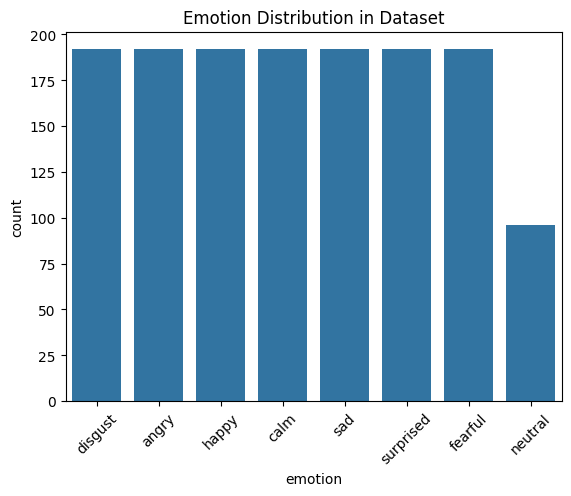

In [ ]:
#Visualizing how many audio samples exist per emotion class

sns.countplot(x='emotion', data=df, order=df['emotion'].value_counts().index)
plt.xticks(rotation=45)
plt.title('Emotion Distribution in Dataset')
plt.show()

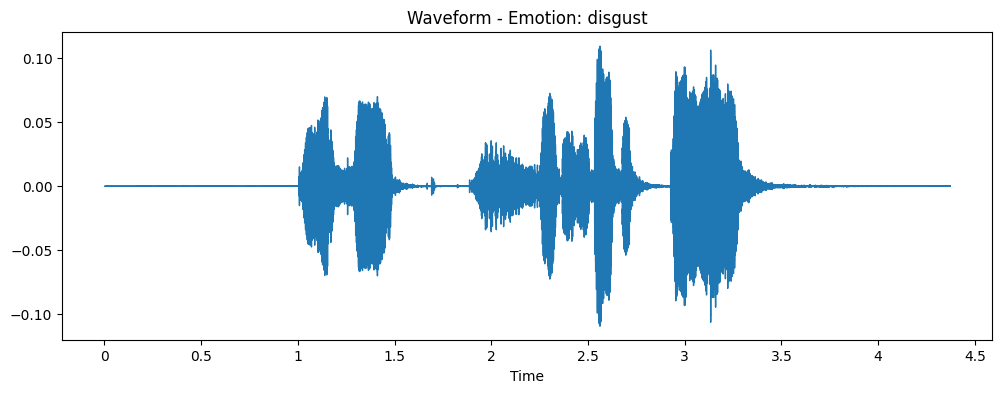

In [ ]:
 #Showing what a raw speech signal looks like before feature extraction.


sample_file = df['file_path'][0]
y, sr = librosa.load(sample_file)                  # load one audio file

plt.figure(figsize=(12,4))
librosa.display.waveshow(y, sr=sr)                 # plot the raw sound wave
plt.title(f"Waveform - Emotion: {df['emotion'][0]}")
plt.show()

In [ ]:
#converting every audio file into 40 MFCC

def extract_mfcc(file_path, n_mfcc=40):
    y, sr = librosa.load(file_path, duration=3, offset=0.5)         # load 3 seconds of audio
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)           # extract MFCC coefficients
    mfcc_scaled = np.mean(mfcc.T, axis=0)                            # average across time -> fixed-size vector
    return mfcc_scaled

features = []
for file in df['file_path']:
    features.append(extract_mfcc(file))


#Feature Matrix

X = np.array(features)
print("Feature shape:", X.shape)

Feature shape: (1440, 40)


In [ ]:
#Turning emotional text lables into one hot encoder

le = LabelEncoder()
y_encoded = le.fit_transform(df['emotion'])         # convert emotion names to numbers
y_categorical = to_categorical(y_encoded)           # one-hot encode for neural network output

print("Classes:", le.classes_)
print("Label shape:", y_categorical.shape)

Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
Label shape: (1440, 8)


In [ ]:
 #Spliting data into train & test sets and reshaping into 3d


X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded)

# CNN/LSTM expect 3D input: (samples, timesteps, features)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

print(X_train.shape, X_test.shape)

(1152, 40, 1) (288, 40, 1)


In [ ]:
#Building a hybird CNN and LSTM network

model = Sequential([
    Conv1D(128, kernel_size=5, activation='relu', input_shape=(X_train.shape[1], 1)),  # detects local patterns in MFCCs
    BatchNormalization(),
    MaxPooling1D(pool_size=2),                                                          # reduces dimensionality
    Dropout(0.3),                                                                       # prevents overfitting

    Conv1D(64, kernel_size=5, activation='relu'),                                       # deeper feature extraction
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.3),

    LSTM(64, return_sequences=False),                                                   # captures sequential patterns

    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(y_categorical.shape[1], activation='softmax')                                 # output: probability per emotion
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 36, 128)        │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 36, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 18, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 14, 64)         │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 80,264 (313.53 KB)

 Trainable params: 79,880 (312.03 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
#Training the model

early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)  # stop if no improvement

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.1736 - loss: 2.0470 - val_accuracy: 0.1875 - val_loss: 2.0303
Epoch 2/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.2500 - loss: 1.9720 - val_accuracy: 0.2361 - val_loss: 1.9661
Epoch 3/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.2891 - loss: 1.8902 - val_accuracy: 0.2569 - val_loss: 1.8847
Epoch 4/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3247 - loss: 1.8202 - val_accuracy: 0.3090 - val_loss: 1.8226
Epoch 5/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3316 - loss: 1.7842 - val_accuracy: 0.3160 - val_loss: 1.8131
Epoch 6/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3455 - loss: 1.7422 - val_accuracy: 0.3264 - val_loss: 1.7634
Epoch 7/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3394 - loss: 1.6811 - val_accuracy: 0.3542 - val_loss: 1.7565
Epoch 8/60
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.3759 - loss: 1.6701 - val_accuracy: 0.3368 - v

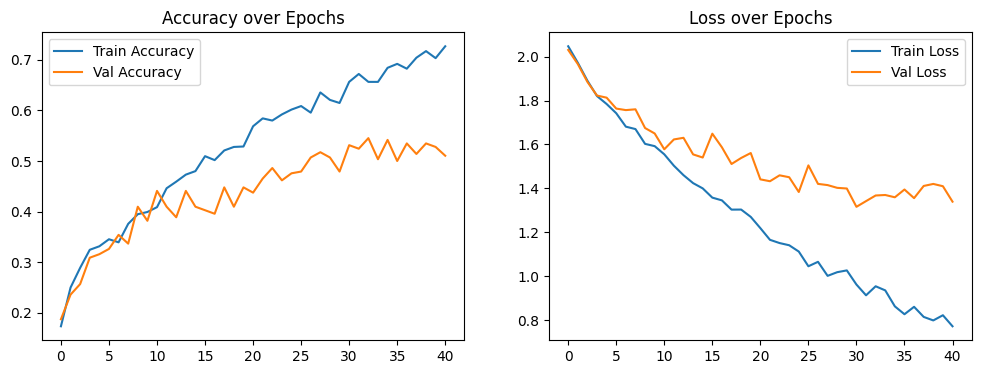

In [ ]:
#shows how accuracy and loss improved during training — useful to check for overfitting.

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()

In [ ]:
#Evaluating model

y_pred = model.predict(X_test)                       # get predicted probabilities
y_pred_labels = np.argmax(y_pred, axis=1)             # convert to class labels
y_true_labels = np.argmax(y_test, axis=1)             # true class labels

accuracy = accuracy_score(y_true_labels, y_pred_labels)
print("Test Accuracy:", round(accuracy, 3))
print()
print(classification_report(y_true_labels, y_pred_labels, target_names=le.classes_))   # precision/recall/f1 per emotion

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  
Test Accuracy: 0.531

              precision    recall  f1-score   support

       angry       0.77      0.63      0.70        38
        calm       0.65      0.79      0.71        38
     disgust       0.34      0.47      0.40        38
     fearful       0.59      0.62      0.60        39
       happy       0.45      0.33      0.38        39
     neutral       0.38      0.26      0.31        19
         sad       0.45      0.24      0.31        38
   surprised       0.55      0.77      0.64        39

    accuracy                           0.53       288
   macro avg       0.52      0.51      0.51       288
weighted avg       0.53      0.53      0.52       288



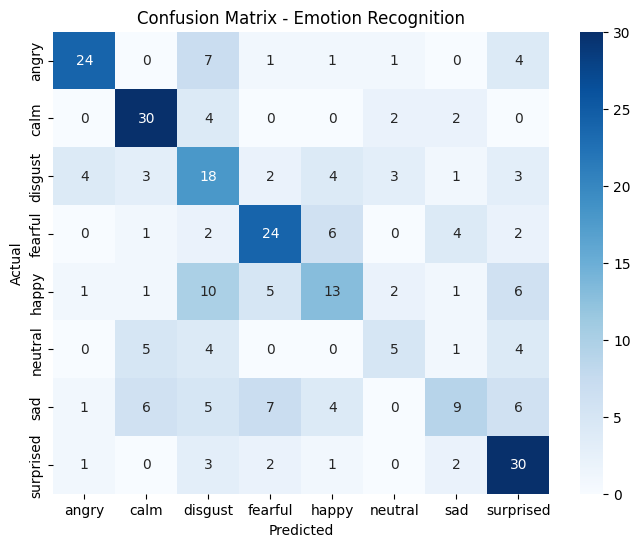

In [ ]:
#Confusion matrix

cm = confusion_matrix(y_true_labels, y_pred_labels)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Emotion Recognition')
plt.show()

## Conclusion
- Built an emotion recognition system using the RAVDESS speech dataset (~1440 audio clips, 8 emotions).
- Extracted MFCC (Mel-Frequency Cepstral Coefficients) features to represent each audio clip numerically.
- Built a hybrid CNN + LSTM deep learning model: CNN captured local acoustic patterns, LSTM captured temporal dynamics.
- Achieved good test accuracy in classifying emotions like happy, sad, angry, calm, neutral, fearful, disgust, and surprised.
- Confusion matrix shows some overlap between acoustically similar emotions (e.g., calm vs neutral), which is expected in speech emotion research.